# Feature Engineering in ML

Feature Engineering is the process of transforming existing data and creating new features that help a machine learning model better understand and represent the underlying patterns in the data. It allows us to generate meaningful features that may not exist directly in the original dataset, potentially improving the model’s performance and ability to make accurate predictions.

In [13]:
import numpy as np
import copy, math
import matplotlib.pyplot as plt
#from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision = 2) # reduced display precision on numpy arrays


In [39]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column
    
    Args:
      X (ndarray (m,n))     : input data, m examples, n features
      
    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    # find the mean of each column/feature
    mu     = np.mean(X, axis=0)                 # mu will have shape (n,)
    # find the standard deviation of each column/feature
    sigma  = np.std(X, axis=0)                  # sigma will have shape (n,)
    # element-wise, subtract mu for that column from each example, divide by std for that column
    X_norm = (X - mu) / sigma 

    return (X_norm)
 
#check our work
#from sklearn.preprocessing import scale
#scale(X_orig, axis=0, with_mean=True, with_std=True, copy=True)

In [15]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar    
    return cost

In [16]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]   
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [53]:
def gradient_descent(X, y, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn w and b. Updates w and b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    w_in = np.zeros_like(X[0])
    b_in = 0.0
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.13f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

# Polynomial Features
### Feature Engineering & Polynomial Regression

Feature Engineering is the process of creating or transforming features to help a machine learning model better represent patterns in the data.

Linear regression can only fit a linear relationship between the features and the target. When the data is nonlinear, we can create polynomial features such as (x^2), (x^3), etc.

For example:

[
y = w_0x + w_1x^2 + b
]

The model is still linear in its parameters, but the engineered features allow it to represent nonlinear relationships.


Without feature engineering, just to see the difference when we apply it, let’s imagine that we created a dataset specifically for training and then plot the shape values to compare the results.

Iteration    0: Cost  1657.56   
Iteration  100: Cost   694.55   
Iteration  200: Cost   588.48   
Iteration  300: Cost   526.41   
Iteration  400: Cost   490.10   
Iteration  500: Cost   468.86   
Iteration  600: Cost   456.43   
Iteration  700: Cost   449.16   
Iteration  800: Cost   444.90   
Iteration  900: Cost   442.41   


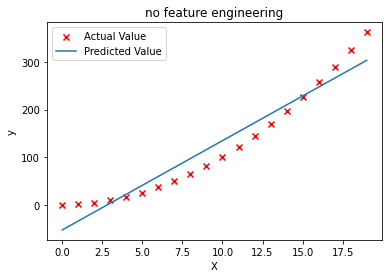

In [18]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

#model_w,model_b = run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-2)
alpha = 1e-2
num_iters = 1000
model_w,model_b,_ = gradient_descent(X, y, compute_cost, compute_gradient, alpha, num_iters)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label="Predicted Value");plt.xlabel("X"); plt.ylabel("y"); 
plt.legend(); 
plt.show()

Iteration    0: Cost  7329.22   
Iteration 1000: Cost     0.22   
Iteration 2000: Cost     0.22   
Iteration 3000: Cost     0.22   
Iteration 4000: Cost     0.22   
Iteration 5000: Cost     0.22   
Iteration 6000: Cost     0.21   
Iteration 7000: Cost     0.21   
Iteration 8000: Cost     0.21   
Iteration 9000: Cost     0.21   


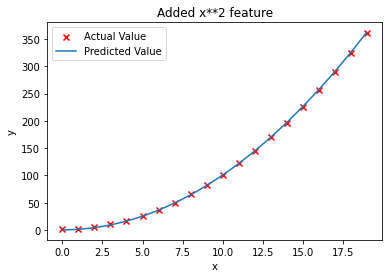

In [19]:
# Engineer features 
X = x**2      #<-- added engineered feature

X = X.reshape(-1, 1)  #X should be a 2-D Matrix
alpha = 1e-5
num_iters = 10000
model_w,model_b,_ = gradient_descent(X, y, compute_cost, compute_gradient, alpha, num_iters)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,model_w) + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); 
plt.legend(); plt.show()

In [20]:
# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature

Iteration    0: Cost  1161.86   
Iteration 1000: Cost   341.85   
Iteration 2000: Cost   291.81   
Iteration 3000: Cost   249.10   
Iteration 4000: Cost   212.64   
Iteration 5000: Cost   181.52   
Iteration 6000: Cost   154.96   
Iteration 7000: Cost   132.28   
Iteration 8000: Cost   112.93   
Iteration 9000: Cost    96.41   


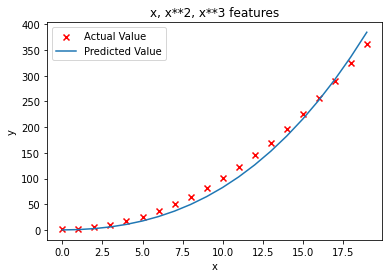

In [21]:
alpha = 1e-7
num_iters = 10000
model_w,model_b,_ = gradient_descent(X, y, compute_cost, compute_gradient, alpha, num_iters)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("x, x**2, x**3 features")
plt.plot(x, X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); 
plt.legend(); plt.show()

In [22]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature
X_features = ['x','x^2','x^3']

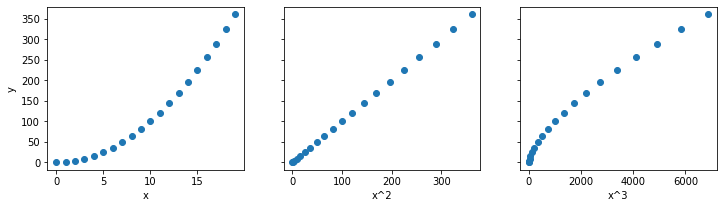

In [23]:
fig,ax=plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.show()

# Scaling features
If the data set has features with significantly different scales, one should apply feature scaling to speed gradient descent. In the example above, there is  𝑥
 ,  $𝑥^2$
  and  $𝑥^3$
  which will naturally have very different scales. Let's apply Z-score normalization to our example.

In [40]:
# create target data
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X,axis=0)}")

# add mean_normalization 
X = zscore_normalize_features(X)     
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X,axis=0)}")

Peak to Peak range by column in Raw        X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.3  3.18 3.28]


#### Now we can try again with a more aggressive value of alpha:
Now you can update the learning rate alpha to check the difference.

Iteration    0: Cost 9421.4668030069715   
Iteration 10000: Cost 0.3909383821637   
Iteration 20000: Cost 0.0278388726361   
Iteration 30000: Cost 0.0019824168335   
Iteration 40000: Cost 0.0001411686656   
Iteration 50000: Cost 0.0000100526750   
Iteration 60000: Cost 0.0000007158549   
Iteration 70000: Cost 0.0000000509763   
Iteration 80000: Cost 0.0000000036300   
Iteration 90000: Cost 0.0000000002585   


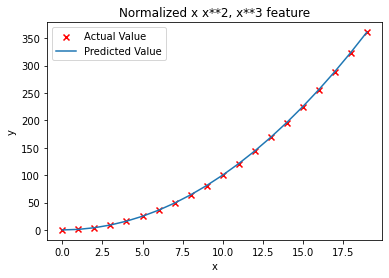

In [54]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x, x**2, x**3]
X = zscore_normalize_features(X) 

alpha = 1e-1
num_iters = 100000
model_w,model_b,_ = gradient_descent(X, y, compute_cost, compute_gradient, alpha, num_iters)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); 
plt.legend(); plt.show()

##### Complex Functions
With feature engineering, even quite complex functions can be modeled:

Iteration    0: Cost 0.2248870612802319   
Iteration 100000: Cost 0.023106201987556932   
Iteration 200000: Cost 0.023106201987556932   
Iteration 300000: Cost 0.023106201987556932   
Iteration 400000: Cost 0.023106201987556932   
Iteration 500000: Cost 0.023106201987556932   
Iteration 600000: Cost 0.023106201987556932   
Iteration 700000: Cost 0.023106201987556932   
Iteration 800000: Cost 0.023106201987556932   
Iteration 900000: Cost 0.023106201987556932   


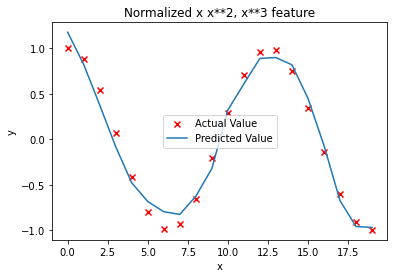

In [50]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X) 

alpha = 1e-1
num_iters = 1000000
model_w,model_b,_ = gradient_descent(X, y, compute_cost, compute_gradient, alpha, num_iters)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); 
plt.ylabel("y"); plt.legend(); plt.show()
